In [149]:
#from google.colab import drive # remove the cell if not using colab
#drive.mount('/content/drive')

In [170]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
base_path = Path('.')
pd.set_option('display.max_columns', None)   

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że gdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
# Twoje zadanie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk klasyfikacji. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk klasyfikacji od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [151]:
titanic_df = pd.read_csv("./titanic_preprocessed.csv")

In [152]:
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,TicketGroupSize,HasCabin,IsAlone,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,1,0,0,0,0,1
1,1,1,1,38.0,1,0,71.2833,2,1,1,0,1,0,0
2,1,3,1,26.0,0,0,7.9250,1,1,0,1,0,0,1
3,1,1,1,35.0,1,0,53.1000,2,2,1,0,0,0,1
4,0,3,0,35.0,0,0,8.0500,1,1,0,1,0,0,1


In [153]:
titanic_df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'TicketGroupSize', 'HasCabin', 'IsAlone', 'Embarked_C',
       'Embarked_Q', 'Embarked_S'],
      dtype='str')

### Podsumowanie zadania 1, wybór metryk klasyfikacji
Cechy kategorialne "Name", "Ticket", "Cabin" same w sobie nie dostarczają dodatkowych informacji. Po wstępnym przetworzeniu:
- cecha Ticket pomaga uzupełnienie brakujących wartości w cesze Fare, dodatkowo wywodzi się z niej cecha numeryczna dyskretna TicketGroupSize
- cecha HasCabin wywodząca się od Cabin determinuje, czy dany pasażer miał przypisaną kajutę

Najprawdpodobniej zbiór danych nie posiada szumów informacyjnych. Wartości odstające w cechach numerycznych są jak najbardziej prawdopodobne ze względu na fakt, że zbiór danych opiera się na rzeczywistej liście pasażerów statku Titanic z początku XX wieku. Wszelkie skrajne obserwacje np. bardzo wysokie ceny biletów Fare w pierwszej klasie lub szeroki przekrój wiekowy Age odzwierciedlają realia historyczne. Jednakże, w celu uniknięcia utrudnień związanych z uczeniem modeli na tym zbiorze danych obserwacje z najbardziej odstającymi wartościami w cechach numerycznych zostały pominięte.

Większość cech numerycznych charakteryzuje się rozkładem skośnym prawostronnie.

Jako metrykę klasyfikacji wytrenowanych modeli przyjmuję precyzję (ang. precision) dla kategorii ocalałych (1) daną wzorem:
$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

W przypadku zbioru danych pasażerów Titanica zależy nam na tym, aby nie budzić fałszywych nadziei wśród rodzin pasażerów. Precyzja uwzględnia błędy typu False Positive (przypadki, w których model niesłusznie sklasyfikował ofiarę jako ocalałego). Im wyższa precyzja, tym mniej fałszywych alarmów, co oznacza, że model rzadko przypisuje status ocalałego komuś, kto w rzeczywistości zginął, zapewniając wysoką wiarygodność pozytywnych predykcji. 

Poniższa metryka:
$$\text{F1}= 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
będzie weryfikować wiarygodność precyzji. Jeśli precyzja jest wysoka, ale czułość drastycznie spada, bo model przypisuje większość ocalałym kategorię 0 F1 obniży się.

### Podział zbioru danych na zbiór treningowy i zbiór testowy

In [154]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(titanic_df.drop(columns=['Survived']), titanic_df['Survived'], test_size=0.2, random_state=42, stratify=titanic_df['Survived'])

### Transformacja i skalowanie cech numerycznych (pipeline)

Decyzja co do transformacji i skalowania cech zostały podjęte na podstawie wykresów oraz ich wniosków z poprzedniego zadania.

In [155]:
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

to_robust = ['Age', 'SibSp', 'Parch', 'FamilySize', 'TicketGroupSize']

preprocessor = ColumnTransformer(
    transformers = [
        ('robust', RobustScaler(), to_robust),
        ('fare_pipeline', Pipeline([
            ('log', FunctionTransformer(np.log1p)),
            ('std', StandardScaler())
        ]), ['Fare'])
    ],
    remainder='passthrough'
)

### DummyClassifier

In [156]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

In [157]:
strategies = ["most_frequent", "stratified", "uniform"]

for strategy in strategies:
    dummy_model = DummyClassifier(strategy=strategy)
    dummy_model.fit(X_train, y_train)
    y_pred = dummy_model.predict(X_test)
    
    print(strategy.capitalize())
    print(classification_report(y_test, y_pred))
    print("-------------------")

Most_frequent
              precision    recall  f1-score   support

           0       0.63      1.00      0.78       106
           1       0.00      0.00      0.00        61

    accuracy                           0.63       167
   macro avg       0.32      0.50      0.39       167
weighted avg       0.40      0.63      0.49       167

-------------------
Stratified
              precision    recall  f1-score   support

           0       0.63      0.67      0.65       106
           1       0.35      0.31      0.33        61

    accuracy                           0.54       167
   macro avg       0.49      0.49      0.49       167
weighted avg       0.53      0.54      0.53       167

-------------------
Uniform
              precision    recall  f1-score   support

           0       0.63      0.54      0.58       106
           1       0.36      0.44      0.39        61

    accuracy                           0.50       167
   macro avg       0.49      0.49      0.49       167
w

c:\Users\XYZ\Desktop\Solvro\ml-wakacyjne-wyzwanie-2026\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\XYZ\Desktop\Solvro\ml-wakacyjne-wyzwanie-2026\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\XYZ\Desktop\Solvro\ml-wakacyjne-wyzwanie-2026\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

### Pierwszy trening modeli
Spośród modeli wybrałem SVC, KNN i DecisionTree. Poniżej przykładowe wyniki modeli z losowo wybranymi hiperparametrami. 

In [158]:
from sklearn.svm import SVC

svc_base_pipe = Pipeline([
    ('prep', preprocessor), 
    ('model', SVC(class_weight='balanced', kernel='linear', random_state=42))
    ])
svc_base_pipe.fit(X_train, y_train)
print(classification_report(y_test, svc_base_pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.89      0.74      0.80       106
           1       0.65      0.84      0.73        61

    accuracy                           0.77       167
   macro avg       0.77      0.79      0.77       167
weighted avg       0.80      0.77      0.78       167



In [159]:
from sklearn.neighbors import KNeighborsClassifier

knn_base_pipe = Pipeline([
    ('prep', preprocessor), 
    ('model', KNeighborsClassifier(n_neighbors=2, metric='cosine'))
    ])
knn_base_pipe.fit(X_train, y_train)
print(classification_report(y_test, knn_base_pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.73      0.93      0.82       106
           1       0.78      0.41      0.54        61

    accuracy                           0.74       167
   macro avg       0.76      0.67      0.68       167
weighted avg       0.75      0.74      0.72       167



In [160]:
from sklearn.tree import DecisionTreeClassifier

dt_base_pipe = Pipeline(
    [('prep', preprocessor), 
     ('model', DecisionTreeClassifier(class_weight='balanced', max_depth=2, random_state=42))
     ])
dt_base_pipe.fit(X_train, y_train)
print(classification_report(y_test, dt_base_pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.89      0.74      0.80       106
           1       0.65      0.84      0.73        61

    accuracy                           0.77       167
   macro avg       0.77      0.79      0.77       167
weighted avg       0.80      0.77      0.78       167



SVC i DT uzyskały dokładnie takie same wyniki precyzji (0,65) i F1 (0,73) na zbiorze testowym. Zapewniają one lepszy ogólny balans i rzadziej pomijają faktycznych ocalałych w porównaniu do drzewa decyzyjnego. Drzewo decyzyjne ma najwyższą precyzję 0,73, ale kosztem czułości. Trudno stwierdzić na tym etapie, który model byłby idealny dla zbioru 'titanic.csv', natomiast do wszystkich trzech modeli hiperparametry albo zostały wylosowane metodą nieempiryczną, albo zostały ustawione domyślne wartości.

### Dobór hiperparametrów za pomocą GridSearchCV

In [161]:
def print_report(model_find):
    print(model_find.best_params_)
    print(f"Najlepszy wynik: {round(model_find.best_score_,3)}")
    print(f"Wynik na zbiorze testowym: {model_find.score(X_test, y_test)}")

In [ ]:
def prepared_tabel(model_find, first_p, second_p, metric):
    tabel = pd.DataFrame(model_find.cv_results_)
    tabel = tabel[[f"param_model__{first_p}", f"param_model__{second_p}", f'mean_test_{metric}', 'mean_test_f1', f'rank_test_{metric}']]
    return tabel.sort_values(f'mean_test_{metric}', ascending=False).head(10)

In [163]:
def show_plot(df, parameter, metric):
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x=f'param_model__{parameter}', y=f'mean_test_{metric}', errorbar=None)
    plt.title(f'Wpływ {parameter} na {metric} modelu')
    plt.show() 

In [164]:
def show_heatmap(df, first_p, second_p, metric):
    pivot_table = df.pivot(
        index=f'param_model__{first_p}',
        columns=f'param_model__{second_p}',
        values=f'mean_test_{metric}'
    )

    plt.figure(figsize=(10,5))
    sns.heatmap(pivot_table, annot=True, cmap='coolwarm', cbar= True, fmt='.3f')
    plt.title(f'Wpływ obu hiperparametrów na {metric} modelu')
    plt.xlabel(f'{second_p}')
    plt.ylabel(f'{first_p}')
    plt.show()

{'model__kernel': 'rbf', 'model__tol': np.float64(0.11)}
Najlepszy wynik: 0.781
Wynik na zbiorze testowym: 0.7678571428571429
    param_model__kernel  param_model__tol  mean_test_precision  mean_test_f1
188                 rbf              0.11             0.781414      0.740981
191                 rbf              0.14             0.780303      0.738223
182                 rbf              0.05             0.780303      0.738223
179                 rbf              0.02             0.780303      0.738223
180                 rbf              0.03             0.780303      0.738223
193                 rbf              0.16             0.780303      0.738223
186                 rbf              0.09             0.780303      0.738223
187                 rbf              0.10             0.780303      0.738223
189                 rbf              0.12             0.780303      0.738223
190                 rbf              0.13             0.780303      0.738223


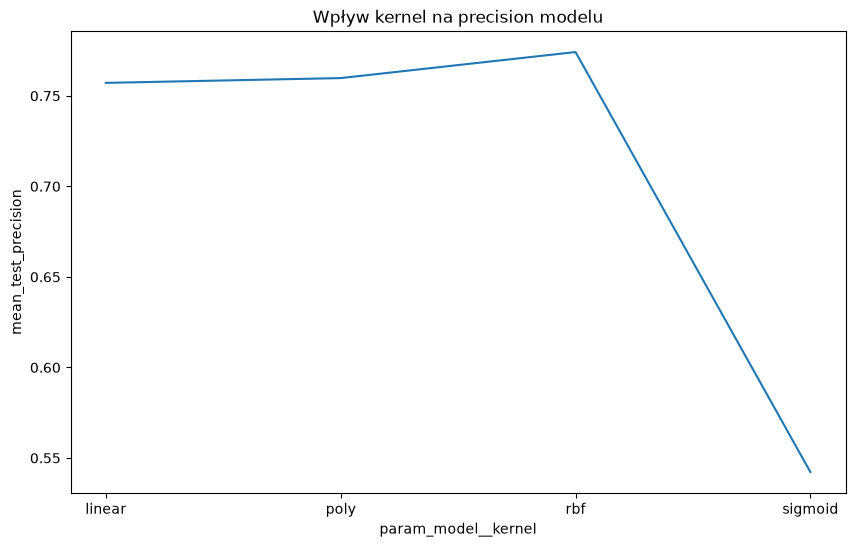

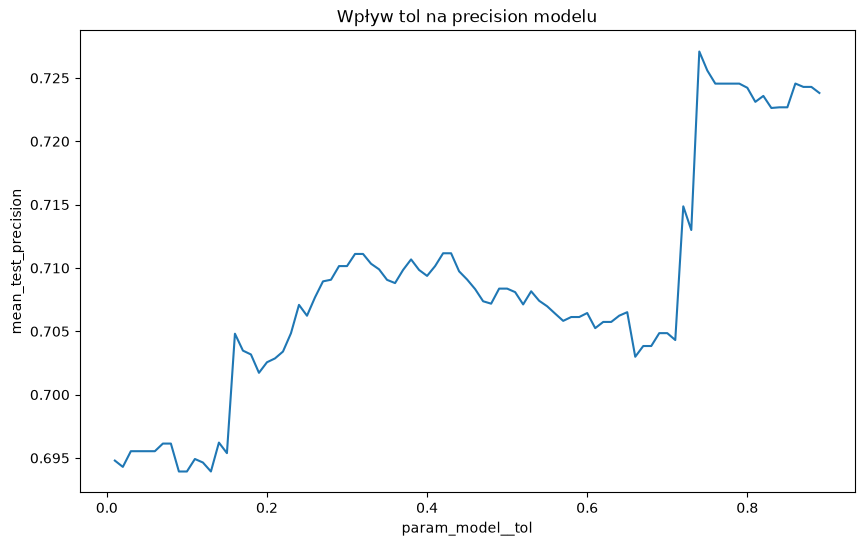

In [174]:
from sklearn.model_selection import GridSearchCV

svc_pipe = Pipeline([
    ('prep', preprocessor), 
    ('model', SVC(random_state=42))
])

svc_grid = {
    'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'model__tol': np.arange(0.01, 0.9, 0.01)
}

svc_find = GridSearchCV(
    svc_pipe,
    svc_grid,
    cv=5,
    scoring = ['precision', 'f1'],
    refit = 'precision',
    n_jobs=2
)

svc_find.fit(X_train, y_train)

print_report(svc_find)
print(prepared_tabel(svc_find, "kernel", "tol", "precision"))

results_df = pd.DataFrame(svc_find.cv_results_)

for hiper in ["kernel", "tol"]:
    show_plot(results_df, hiper, "precision")


Dla ('rbf', 0.11) osiągnięto:
- precision = 0.78 vs 0,65
- f1 = 0.74 vs 0,73


{'model__metric': 'manhattan', 'model__n_neighbors': 4}
Najlepszy wynik: 0.793
Wynik na zbiorze testowym: 0.8461538461538461
    param_model__n_neighbors param_model__metric  mean_test_precision  \
7                          4           manhattan             0.792517   
1                          4           euclidean             0.790400   
25                         4           minkowski             0.790400   
9                          6           manhattan             0.770023   
27                         6           minkowski             0.768917   
3                          6           euclidean             0.768917   
11                         8           manhattan             0.766528   
29                         8           minkowski             0.758417   
5                          8           euclidean             0.758417   
10                         7           manhattan             0.750445   

    mean_test_f1  
7       0.650661  
1       0.655503  
25      0.6555

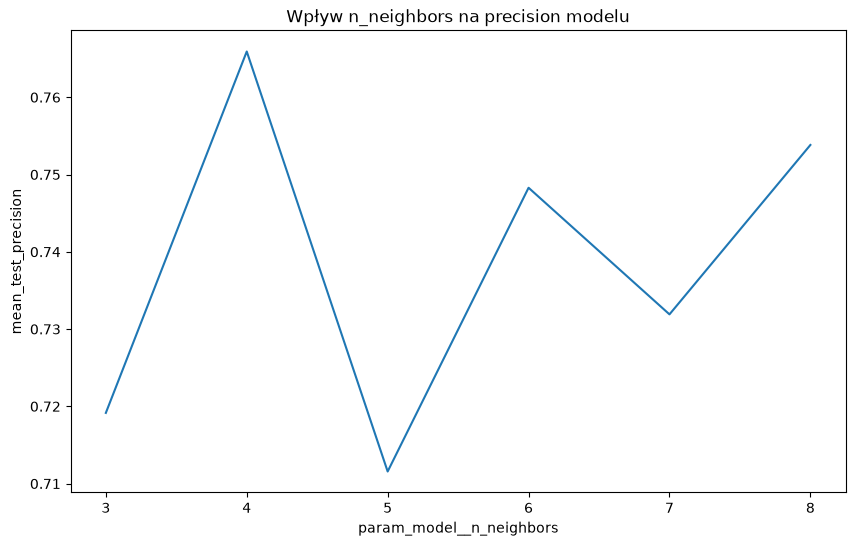

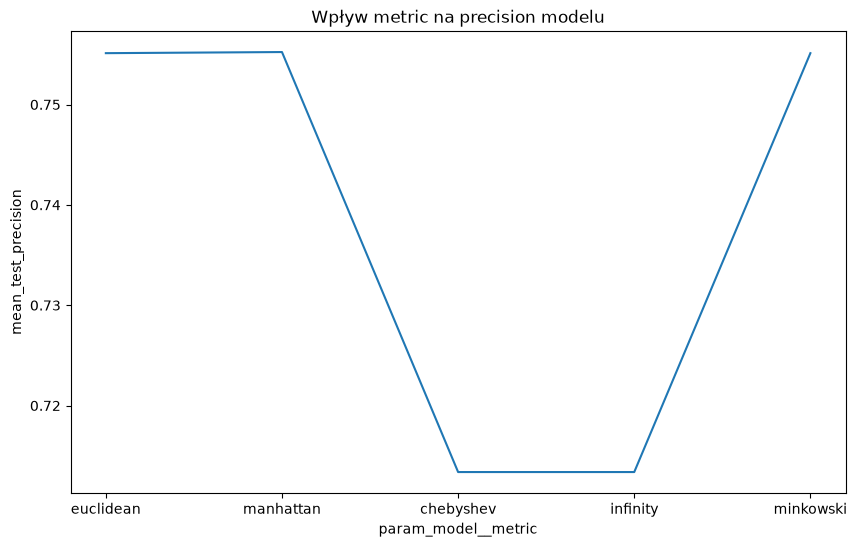

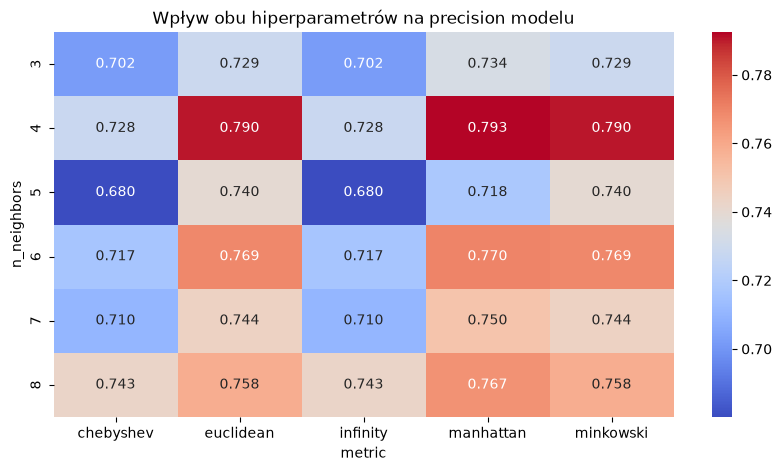

In [176]:
from sklearn.model_selection import GridSearchCV

knn_pipe = Pipeline([
    ('prep', preprocessor), 
    ('model', KNeighborsClassifier())
])

knn_grid = {
    'model__n_neighbors': range(3,9),
    'model__metric': ['euclidean', 'manhattan', 'chebyshev', 'infinity', 'minkowski']
}

knn_find = GridSearchCV(
    knn_pipe,
    knn_grid,
    cv=5,
    scoring = ['precision', 'f1'],
    refit = 'precision',
    n_jobs=2
)

knn_find.fit(X_train, y_train)

print_report(knn_find)

print(prepared_tabel(knn_find, "n_neighbors", "metric", "precision"))

results_df = pd.DataFrame(knn_find.cv_results_)

for hiper in ["n_neighbors", "metric"]:
    show_plot(results_df, hiper, "precision")

show_heatmap(results_df, "n_neighbors", "metric", "precision")

Dla (4, 'manhattan') osiągnięto:
- precision = 0.79 vs 0,78
- f1 = 0.65 vs 0,54

{'model__criterion': 'gini', 'model__max_depth': 2}
Najlepszy wynik: 0.792
Wynik na zbiorze testowym: 0.9090909090909091
   param_model__criterion  param_model__max_depth  mean_test_precision  \
0                    gini                       2             0.792352   
10                entropy                       2             0.792352   
20               log_loss                       2             0.792352   
3                    gini                       5             0.775478   
23               log_loss                       5             0.766789   
13                entropy                       5             0.766789   
5                    gini                       7             0.766354   
22               log_loss                       4             0.755153   
12                entropy                       4             0.755153   
2                    gini                       4             0.747506   

    mean_test_f1  
0       0.605021  
10      0.605021  
20     

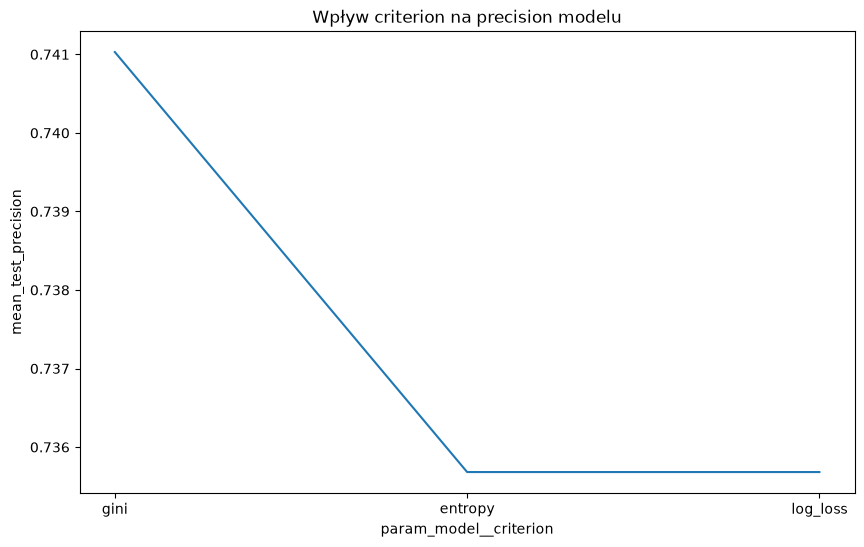

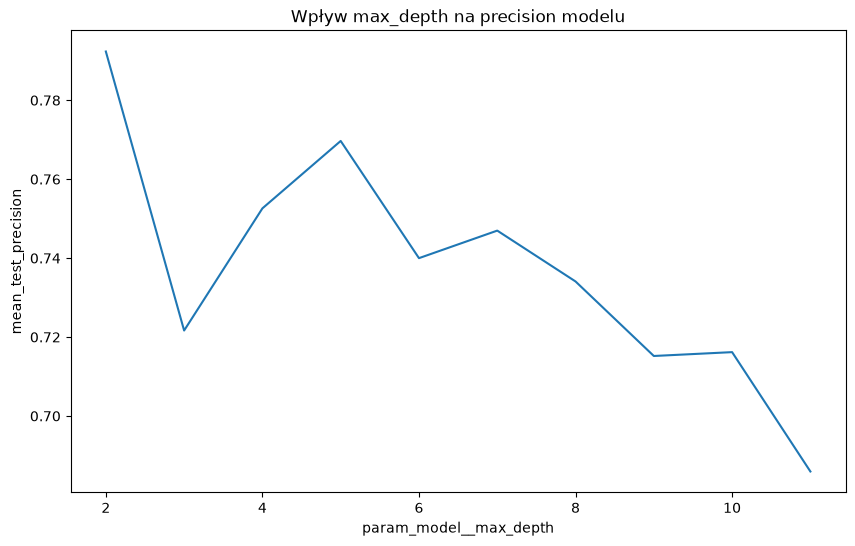

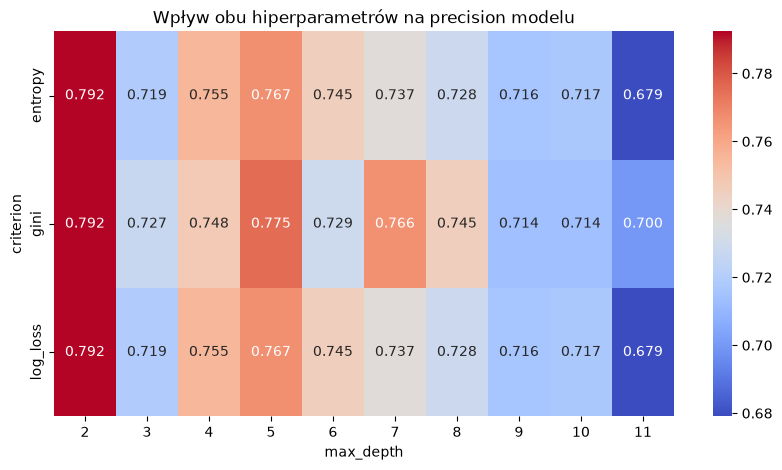

In [177]:
from sklearn.model_selection import GridSearchCV

dt_pipe = Pipeline([
    ('prep', preprocessor), 
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_grid = {
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': range(2,12)
}

dt_find = GridSearchCV(
    dt_pipe,
    dt_grid,
    cv=5,
    scoring = ['precision', 'f1'],
    refit = 'precision',
    n_jobs=2
)

dt_find.fit(X_train, y_train)

print_report(dt_find)

print(prepared_tabel(dt_find, "criterion", "max_depth", "precision"))

results_df = pd.DataFrame(dt_find.cv_results_)

for hiper in ["criterion", "max_depth"]:
    show_plot(results_df, hiper, "precision")

show_heatmap(results_df, 'criterion', 'max_depth', 'precision')

Dla ('gini', 2) osiągnięto:
- precision: 0.79 vs 0,78 
- f1: 0.6 vs 0,63

### Wnioski końcowe

Wartości hiperparametrów poszczególnych modeli nie zawsze dawały większą uśrednioną precyzję i f1 w porównaniu do wartości domyślnych. Z wiązku z przyjęciem metryk precyzji i f1 do pomiaru efektywności modeli zdarzają się takie sytuacje, że nie zawsze pierwszy rekord w tabeli najlepszych wyników rzeczywiście jest najlepszy. Obniżenie precyzji (jako głównej metryki przy sortowaniu w tabeli) może spowodować wzrost f1, taki że precision_1 - precision_n < f1_n - f1_1.
